In [1]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import math
from tqdm import tqdm
import os

In [2]:
rave_sim_dir = Path('/mnt/d/rave-sim-main/rave-sim-main')
simulations_dir = Path('/mnt/d/rave-sim-main/rave-sim-main/output')
scratch_dir = simulations_dir

In [3]:
sys.path.insert(0, str(rave_sim_dir / "big-wave"))
#print(str(rave_sim_dir / "big-wave"))
import multisim
import config
import util

In [4]:
config_dict = {
    "sim_params": {
        "is2d":False,
        "N": 2**24,
        "dx": 3.1e-10,
        "z_detector": 4.6,
        "detector_size": 3e-3,
        "detector_pixel_size_x": 20e-6,
        "detector_pixel_size_y": 1,
        "chunk_size": 256 * 1024 * 1024 // 16,  # use 256MB chunks
    },
    "use_disk_vector": False,
    "save_final_u_vectors": False,
    "dtype": "c8",
    "multisource": {
        "type": "points",
        "energy_range": [10000, 50000],
        "x_range": [-3e-6, 3e-6],
        "z": 0.0,
        "nr_source_points": 1,
        "seed": 1,
        "spectrum": "/mnt/d/rave-sim-main/rave-sim-main/spectrum/spectrum_25keV.h5",
    },
    "elements": [
        {
            "type": "sample",
            "z_start": 0.8,
            "pixel_size_x": 5 * 1e-6,
            "pixel_size_z": 5 * 1e-6,
            "grid_path":"/mnt/d/rave-sim-main/rave-sim-main/grid/square_grid_020_1_5_5.npy",
            "materials": [["C", 1.3]],
            "x_positions":[0],
        },
        {
            "type": "sample",
            "z_start": 0.81,
            "pixel_size_x": 5 * 1e-6,
            "pixel_size_z": 5 * 1e-6,
            "grid_path":"/mnt/d/rave-sim-main/rave-sim-main/grid/square_grid_020_1_5_5.npy",
            "materials": [["C", 1.3]],
            "x_positions":[0],
        },
    ],
}

print("N: ", config_dict["sim_params"]["N"])

N:  16777216


In [5]:
sim_path = multisim.setup_simulation(config_dict, Path("."), simulations_dir)

2026-03-28 20:53:21,161 INFO: Setting up simulation
2026-03-28 20:53:21,244 INFO: Finished setting up simulation in /mnt/d/rave-sim-main/rave-sim-main/output/2026/03/20260328_205321186445


1 1
1 1


In [6]:
computed = config.load(Path(sim_path / 'computed.yaml'))

#print("cutoff angles:", computed['cutoff_angles'])
#print("source points:", computed['source_points'])

In [7]:
# Run this in a for loop to simulate all source points or
# alternatively run the source points as individual euler
# jobs
#for i in range(20):
#    multisim.run_single_simulation(sim_path, i, scratch_dir, save_keypoints_path=scratch_dir)
for i in tqdm(range(config_dict["multisource"]["nr_source_points"])):
    os.system(f"CUDA_VISIBLE_DEVICES=0 /mnt/d/rave-sim-main/rave-sim-main/fast-wave/build-Release/fastwave -s {i} {sim_path}")

  0%|                                                                                             | 0/1 [00:00<?, ?it/s]

[2026-03-28 20:53:21.404] [info] Running simulation /mnt/d/rave-sim-main/rave-sim-main/output/2026/03/20260328_205321186445/00000000
[2026-03-28 20:53:21.725] [info] Simulating optical element 1/2
[2026-03-28 20:53:21.725] [info] PreciseSample info:
[2026-03-28 20:53:21.725] [info]   z_len: 401, x_len: 81
[2026-03-28 20:53:21.725] [info]   material_deltabetas size: 2
[2026-03-28 20:53:21.725] [info]   Material 0: (0, 0)
[2026-03-28 20:53:21.725] [info]   Material 1: (5.58575072687708e-07, 2.190806713129272e-10)
[2026-03-28 20:53:24.251] [info] Elapsed time for optical element: 2428.7493 ms
[2026-03-28 20:53:24.256] [info] Simulating optical element 2/2
[2026-03-28 20:53:24.256] [info] PreciseSample info:
[2026-03-28 20:53:24.256] [info]   z_len: 401, x_len: 81
[2026-03-28 20:53:24.256] [info]   material_deltabetas size: 2
[2026-03-28 20:53:24.256] [info]   Material 0: (0, 0)
[2026-03-28 20:53:24.256] [info]   Material 1: (5.58575072687708e-07, 2.190806713129272e-10)


100%|█████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:05<00:00,  5.56s/it]

[2026-03-28 20:53:26.736] [info] Elapsed time for optical element: 2364.07 ms
[2026-03-28 20:53:26.753] [info] Simulation finished in 5.348752025 seconds


In [8]:
wavefronts = util.load_wavefronts_filtered(sim_path, x_range=(-30e-6, 30e-6))
print("nr sources loaded:", len(wavefronts))
wavef= [result[0] for result in wavefronts]
wf = np.sum(wavef, axis=0)
print("nr phase steps:", wf.shape[0])
print("nr detector pixels:", wf.shape[1])

nr sources loaded: 1
nr phase steps: 1
nr detector pixels: 150


[7.9908460e-07 9.3036056e-07 9.4591115e-07 9.4514775e-07 9.4537802e-07
 9.4450314e-07 9.4576330e-07 9.4449024e-07 9.4496232e-07 9.4586397e-07
 9.4551910e-07 9.4489013e-07 9.4539587e-07 9.4535710e-07 9.4529787e-07
 9.4518413e-07 9.4501576e-07 9.4509016e-07 9.4487467e-07 9.4499734e-07
 9.4535648e-07 9.4494845e-07 9.4486393e-07 9.4503275e-07 9.4513081e-07
 9.4494692e-07 9.4499745e-07 9.4485694e-07 9.4450229e-07 9.4450508e-07
 9.4488405e-07 9.4460751e-07 9.4457420e-07 9.4471409e-07 9.4470431e-07
 9.4448097e-07 9.4482994e-07 9.4421290e-07 9.4464900e-07 9.4556839e-07
 9.4783871e-07 9.2949421e-07 1.0658224e-06 9.8973510e-07 6.7266035e-07
 9.2232352e-07 1.0983292e-06 9.2968406e-07 9.4785463e-07 9.4428634e-07
 9.4485125e-07 9.4567332e-07 9.4464923e-07 9.4512291e-07 9.4499711e-07
 9.4505435e-07 9.4478014e-07 9.4468629e-07 9.4463269e-07 9.4436484e-07
 9.4471505e-07 9.4495130e-07 9.4462075e-07 9.4472233e-07 9.4484403e-07
 9.4488274e-07 9.4472506e-07 9.4488303e-07 9.4502354e-07 9.4483886e-07
 9.450

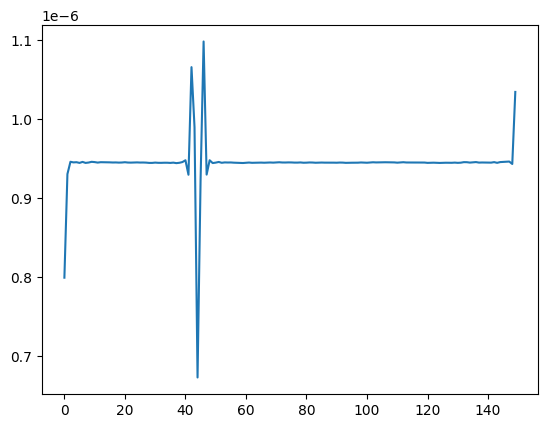

In [9]:
sp = config_dict["sim_params"]
detector_x = util.detector_x_vector(sp["detector_size"], sp["detector_pixel_size_x"])
plt.plot(wf[0])
print(wf[0])
# print(detector_x)

## History

To see the interference pattern in empty space, we can record slices throughout the simulation and then plot them. `run_single_simulation` takes an optional argument `history_dz` defining the resolution with which we record the history.

Note that the history is not necessarily recorded with a constant z-spacing. Inside gratings and samples, one slice is recorded for every step. The history also records a list of z-coordinates at which the slices were recorded, which we can use for plotting.

In [ ]:
multisim.run_single_simulation(sim_path, 1, scratch_dir, save_keypoints_path=None, history_dz=0.02)

In [ ]:
# Path to the directory for the source with index 1
source_dir = multisim.get_sub_dir(sim_path, 1)

hist_x = np.load(source_dir / "history_x.npy")
hist_z = np.load(source_dir / "history_z.npy")
hist = np.load(source_dir / "history.npy")
plt.pcolormesh(
    hist_z,
    hist_x,
    hist,
    cmap="Greys_r",
    vmin=0,
    vmax=1e-6,
    shading="nearest",
)
plt.xlabel("z (m)")
plt.ylabel("x (m)")